# FORMULA 1 DATASET EDA

# 1. Setup

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns

sns.set_theme(style = 'whitegrid')
pd.set_option("display.max_columns", 100)

PROJECT_ROOT = Path("..").resolve()
RAW_DIR = PROJECT_ROOT / "data" / "raw" 

RAW_DIR


WindowsPath('C:/Users/Harsh Tiwari/OneDrive/Desktop/Projects/f1-podium-production/data/raw')

In [14]:
assert RAW_DIR.exists(), f'Raw dataset folder not found : {RAW_DIR}'
sorted([p.name for p in RAW_DIR.glob("*.csv")])

['circuits.csv',
 'constructors.csv',
 'drivers.csv',
 'qualifying.csv',
 'races.csv',
 'results.csv']

## 2. Load Core Tables

In [15]:
races = pd.read_csv(RAW_DIR / 'races.csv')
results = pd.read_csv(RAW_DIR / 'results.csv')
drivers = pd.read_csv(RAW_DIR / 'drivers.csv')
constructors = pd.read_csv(RAW_DIR / 'constructors.csv')
qualifying = pd.read_csv(RAW_DIR / 'qualifying.csv')
circuits = pd.read_csv(RAW_DIR / 'circuits.csv')

tables = {
    'races' : races,
    'results' : results,
    'drivers' : drivers,
    'constructors' : constructors,
    'qualifying' : qualifying,
    'circuits' : circuits
}

pd.DataFrame(
    [{'tables': name , 'rows' : len(df) , 'columns': df.shape[1]} for name, df in tables.items()]
)

,tables,rows,columns
0,races,1125,18
1,results,26759,18
2,drivers,861,9
3,constructors,212,5
4,qualifying,10494,9
5,circuits,77,9


In [16]:
for name , df in tables.items():
    print(f'\n{name.upper()}')
    display(df.head(5))


RACES


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N



RESULTS


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1



DRIVERS


...

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso



QUALIFYING


,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236



CIRCUITS


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


# 3. Missing Values

In [17]:
def Missing_report(df: pd.DataFrame):
    report = pd.DataFrame({
        'missing_count' : df.isnull().sum(),
        'missing_pct' : df.isna().mean() * 100
    })
    return report[report['missing_count'] > 0].sort_values(by = 'missing_pct', ascending = False)

for name , df in tables.items():
    print(f'\n{name.upper()}')
    display(Missing_report(df))


RACES


,missing_count,missing_pct



RESULTS


,missing_count,missing_pct



DRIVERS


...

,missing_count,missing_pct



QUALIFYING


,missing_count,missing_pct
q3,46,0.438346
q2,22,0.209644



CIRCUITS


,missing_count,missing_pct


## 4. Build Analysis Table

In [18]:
analysis_df = (
    results.merge(
        races[["raceId", "year", "round", "circuitId", "name", "date"]].rename(columns={"name": "race_name"}),
        on="raceId",
        how="left",
    )
    .merge(
        drivers[["driverId", "driverRef", "forename", "surname", "nationality"]].rename(
            columns={"nationality": "driver_nationality"}
        ),
        on="driverId",
        how="left",
    )
    .merge(
        constructors[["constructorId", "constructorRef", "name", "nationality"]].rename(
            columns={"name": "constructor_name", "nationality": "constructor_nationality"}
        ),
        on="constructorId",
        how="left",
    )
    .merge(
        circuits[["circuitId", "circuitRef", "country"]].rename(columns={"country": "circuit_country"}),
        on="circuitId",
        how="left",
    )
)

analysis_df["driver_name"] = analysis_df["forename"].fillna("") + " " + analysis_df["surname"].fillna("")
analysis_df["is_podium"] = (pd.to_numeric(analysis_df["positionOrder"], errors="coerce") <= 3).astype(int)
analysis_df["grid"] = pd.to_numeric(analysis_df["grid"], errors="coerce")
analysis_df["points"] = pd.to_numeric(analysis_df["points"], errors="coerce")

analysis_df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,round,circuitId,race_name,date,driverRef,forename,surname,driver_nationality,constructorRef,constructor_name,constructor_nationality,circuitRef,circuit_country,driver_name,is_podium
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,2008,1,1,Australian Grand Prix,2008-03-16,hamilton,Lewis,Hamilton,British,mclaren,McLaren,British,albert_park,Australia,Lewis Hamilton,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1,2008,1,1,Australian Grand Prix,2008-03-16,heidfeld,Nick,Heidfeld,German,bmw_sauber,BMW Sauber,German,albert_park,Australia,Nick Heidfeld,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1,2008,1,1,Australian Grand Prix,2008-03-16,rosberg,Nico,Rosberg,German,williams,Williams,British,albert_park,Australia,Nico Rosberg,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1,2008,1,1,Australian Grand Prix,2008-03-16,alonso,Fernando,Alonso,Spanish,renault,Renault,French,albert_park,Australia,Fernando Alonso,0
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1,2008,1,1,Australian Grand Prix,2008-03-16,kovalainen,Heikki,Kovalainen,Finnish,mclaren,McLaren,British,albert_park,Australia,Heikki Kovalainen,0


## 5. Target Distribution

,counts
is_podium,
Not Podium,23362
Podium,3397


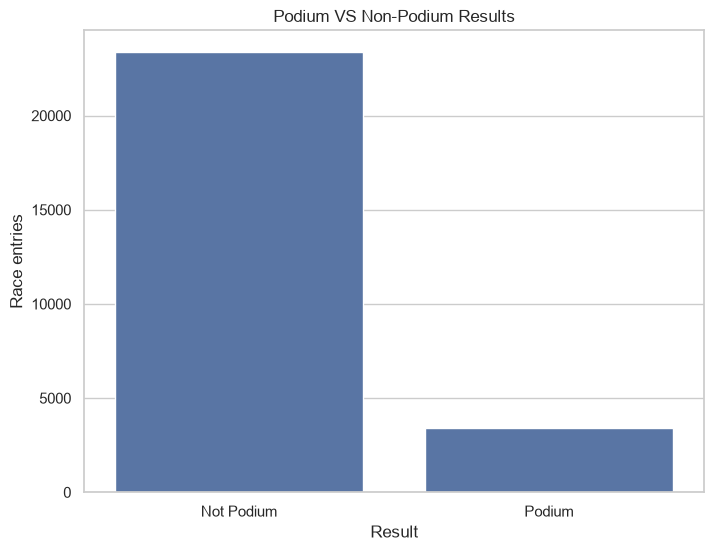

In [19]:
target_counts = analysis_df['is_podium'].value_counts().rename(index = { 0 : 'Not Podium' , 1 : 'Podium'})
display(target_counts.to_frame('counts'))

plt.figure(figsize= (8, 6))
sns.barplot(x = target_counts.index , y = target_counts.values)
plt.title('Podium VS Non-Podium Results')
plt.ylabel('Race entries')
plt.xlabel('Result')
plt.show()

## 6. Podiums by Driver

            driver_name  is_podium
523      Lewis Hamilton        202
578  Michael Schumacher        155
765    Sebastian Vettel        122
571      Max Verstappen        112
256     Fernando Alonso        106
8           Alain Prost        106
502      Kimi Räikkönen        103
62         Ayrton Senna         80
754  Rubens Barrichello         68
831     Valtteri Bottas         67
180     David Coulthard         62
608       Nelson Piquet         60
617       Nigel Mansell         59
614        Nico Rosberg         57
618          Niki Lauda         54


C:\Users\Harsh Tiwari\AppData\Local\Temp\ipykernel_16248\5149051.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_driver_podiums , x = 'is_podium', y = 'driver_name', palette = 'viridis')


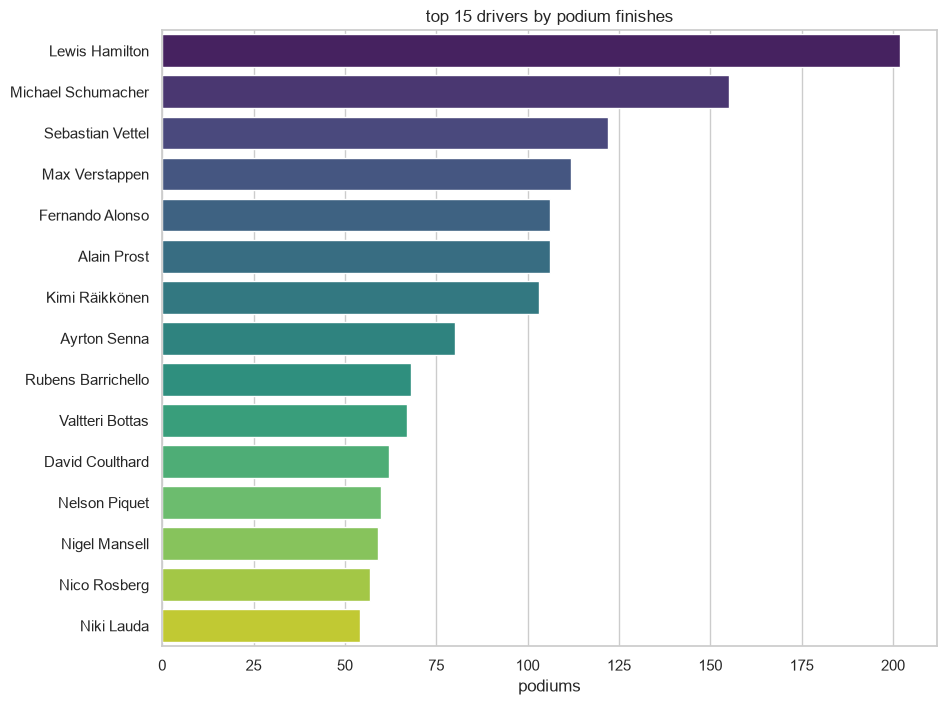

In [20]:
top_driver_podiums = (
    analysis_df.groupby('driver_name' , as_index = False)['is_podium'].sum()
    .sort_values("is_podium", ascending = False)
    .head(15)
)
print(top_driver_podiums)

plt.figure(figsize=(10,8))
sns.barplot(data = top_driver_podiums , x = 'is_podium', y = 'driver_name', palette = 'viridis')
plt.title('top 15 drivers by podium finishes')
plt.xlabel('podiums')
plt.ylabel('')
plt.show()

## Podiums by Constructor

    constructor_name  is_podium
73           Ferrari        841
134          McLaren        508
208         Williams        314
139         Mercedes        298
166         Red Bull        282
191       Team Lotus        114
167          Renault        103
23          Benetton        102
25           Brabham         78
202          Tyrrell         77
18               BRM         61
109           Ligier         50
46     Cooper-Climax         44
130         Maserati         40
115     Lotus-Climax         31


C:\Users\Harsh Tiwari\AppData\Local\Temp\ipykernel_16248\141395996.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_constructor_podiums , x = 'is_podium' , y = 'constructor_name' , palette = 'magma')


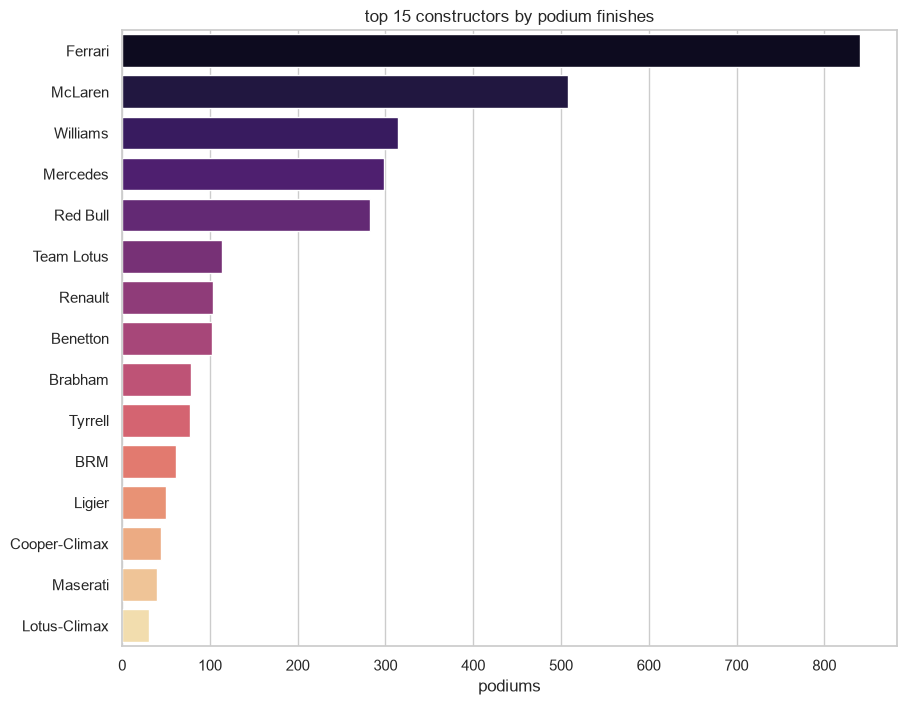

In [21]:
top_constructor_podiums = (
    analysis_df.groupby('constructor_name' , as_index = False)['is_podium'].sum()
    .sort_values('is_podium' , ascending = False)
    .head(15)
)
print(top_constructor_podiums)

plt.figure(figsize = (10,8))
sns.barplot(data = top_constructor_podiums , x = 'is_podium' , y = 'constructor_name' , palette = 'magma')
plt.title('top 15 constructors by podium finishes') 
plt.xlabel('podiums')
plt.ylabel('')
plt.show()     


## 8. Grid Position vs Podium Probability

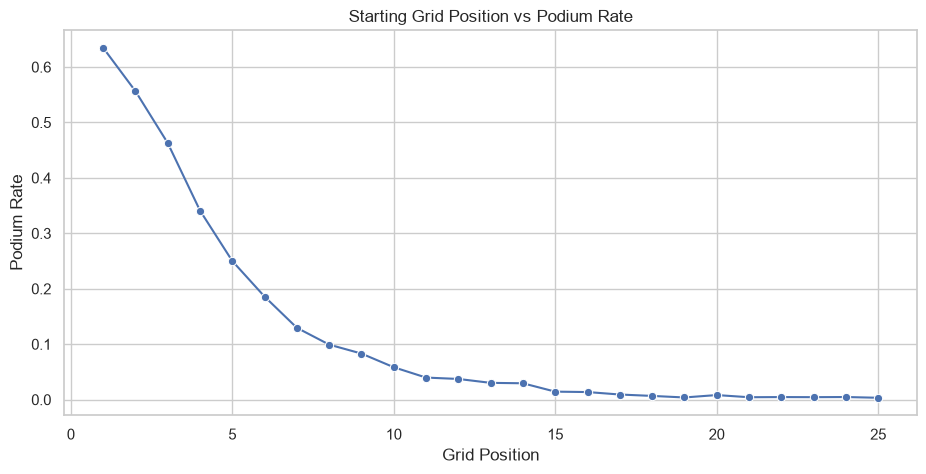

,grid,entries,podium_rate
0,1,1136,0.634683
1,2,1125,0.556444
2,3,1130,0.462832
3,4,1132,0.340989
4,5,1132,0.250000
5,6,1125,0.185778
6,7,1135,0.129515
7,8,1129,0.099203
8,9,1132,0.083039
9,10,1130,0.058407


In [22]:
grid_df = analysis_df[(analysis_df['grid']> 0) & (analysis_df['grid'] <= 25)].copy()
grid_summary = (
    grid_df.groupby('grid', as_index = False)
    .agg(entries =('is_podium', 'size'), podium_rate= ('is_podium', 'mean'))
)

plt.figure(figsize=(11, 5))
sns.lineplot(data=grid_summary, x="grid", y="podium_rate", marker="o")
plt.title("Starting Grid Position vs Podium Rate")
plt.xlabel("Grid Position")
plt.ylabel("Podium Rate")
plt.show()

grid_summary.head(15)

## 9. Qualifying Position vs Final Result

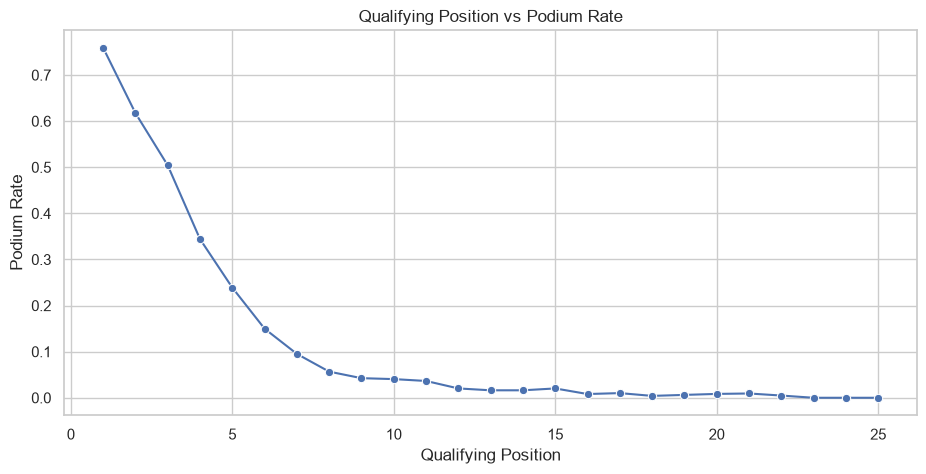

,qualifying_position,entries,podium_rate
0,1.0,494,0.759109
1,2.0,494,0.617409
2,3.0,494,0.504049
3,4.0,494,0.344130
4,5.0,494,0.238866
5,6.0,494,0.149798
6,7.0,494,0.095142
7,8.0,494,0.056680
8,9.0,494,0.042510
9,10.0,494,0.040486


In [23]:
qual_df = qualifying[["raceId", "driverId", "constructorId", "position"]].rename(
    columns={"position": "qualifying_position"}
)
qual_analysis = analysis_df.merge(
    qual_df,
    on=["raceId", "driverId", "constructorId"],
    how="left",
)
qual_analysis["qualifying_position"] = pd.to_numeric(qual_analysis["qualifying_position"], errors="coerce")

qual_summary = (
    qual_analysis[qual_analysis["qualifying_position"].between(1, 25)]
    .groupby("qualifying_position", as_index=False)
    .agg(entries=("is_podium", "size"), podium_rate=("is_podium", "mean"))
)

plt.figure(figsize=(11, 5))
sns.lineplot(data=qual_summary, x="qualifying_position", y="podium_rate", marker="o")
plt.title("Qualifying Position vs Podium Rate")
plt.xlabel("Qualifying Position")
plt.ylabel("Podium Rate")
plt.show()

qual_summary.head(15)


## 10. Yearly Race Entries and Podium Rate

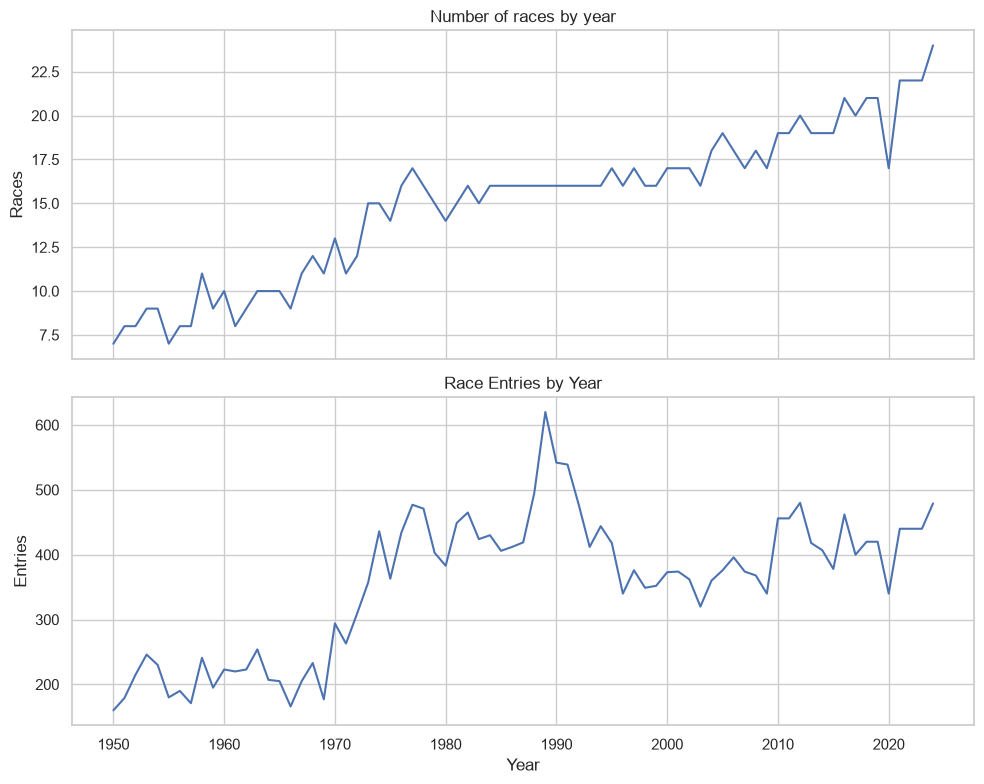

,year,entries,podium_rate,races
65,2015,378,0.150794,19
66,2016,462,0.136364,21
67,2017,400,0.150000,20
68,2018,420,0.150000,21
69,2019,420,0.150000,21
70,2020,340,0.150000,17
71,2021,440,0.150000,22
72,2022,440,0.150000,22
73,2023,440,0.150000,22
74,2024,479,0.150313,24


In [24]:
yearly = (
    analysis_df.groupby('year' , as_index = False)
    .agg(entries= ('is_podium', 'size') , podium_rate = ('is_podium' , 'mean'), races=("raceId", "nunique"))
)

fig , axes = plt.subplots(2, 1 , figsize = (10, 8), sharex = True)
sns.lineplot(data = yearly , x = 'year', y = 'races', ax = axes[0])
axes[0].set_title('Number of races by year')
axes[0].set_ylabel('Races')

sns.lineplot(data = yearly , x = 'year', y = 'entries', ax= axes[1] )
axes[1].set_title("Race Entries by Year")
axes[1].set_ylabel("Entries")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.show()

yearly.tail(10)

## 11. Strongest Recent Drivers and Constructors

In [28]:
recent_start_year = max(analysis_df['year'].max() -10 , analysis_df['year'].min())
recent = analysis_df[analysis_df['year'] >= recent_start_year]

recent_drivers = (
    recent.groupby('driver_name' , as_index= False)
    .agg(entries = ('is_podium', 'size'), podiums = ('is_podium', 'sum'), podium_rate = ('is_podium', 'mean'))
    .query("entries >= 20")
    .sort_values(["podium_rate", 'podiums'], ascending = False)
    .head(15)
)

recent_constructors = (
    recent.groupby('constructor_name', as_index= False)
    .agg(entries  =("is_podium", "size"), podiums=("is_podium", "sum"), podium_rate=("is_podium", "mean"))
    .query("entries >= 20")
    .sort_values(["podium_rate", "podiums"], ascending=False)
    .head(15)
)

display(recent_drivers)
display(recent_constructors)

,driver_name,entries,podiums,podium_rate
38,Nico Rosberg,59,46,0.779661
29,Lewis Hamilton,227,148,0.651982
34,Max Verstappen,209,112,0.535885
52,Sebastian Vettel,180,60,0.333333
56,Valtteri Bottas,228,67,0.293860
7,Charles Leclerc,149,43,0.288591
42,Oscar Piastri,46,10,0.217391
28,Lando Norris,128,26,0.203125
26,Kimi Räikkönen,158,26,0.164557
54,Sergio Pérez,226,36,0.159292


,constructor_name,entries,podiums,podium_rate
12,Mercedes,456,266,0.583333
15,Red Bull,456,178,0.390351
5,Ferrari,456,151,0.331140
11,McLaren,456,41,0.089912
14,Racing Point,76,4,0.052632
3,Aston Martin,180,9,0.050000
19,Williams,455,16,0.035165
2,Alpine F1 Team,180,6,0.033333
6,Force India,200,5,0.025000
16,Renault,200,3,0.015000
